# The concurrency envelope

This notebook derives the paper's Tables II and III and the generic-load
results from the raw benchmark logs in `docs/paper/artifacts/`. The
primary campaigns (2026-08-10) use a soak-and-measure protocol: each
concurrent or decode-alone phase is measured only after a decode soak
reaches the firmware's governed thermal plateau, over windows long
enough for 12 to 28 flood completions. The earlier short-window
campaign (`conc_bench2/`) measured a thermal transient and reads 10 to
15% differently in both directions; it is kept for comparison. The
windowing rule lives in `pi/flood/analyze_conc_bench.py`.

In [1]:
import re, statistics, subprocess, sys
from pathlib import Path

ART = Path("../docs/paper/artifacts")
def analyze(d, steps=4000):
    out = subprocess.run([sys.executable, "../pi/flood/analyze_conc_bench.py", str(d), str(steps)],
                         capture_output=True, text=True)
    print(out.stdout)

print("=== steady-state (Table II) ===")
analyze(ART / "conc_steady_2026-08-10")
print("=== earlier transient campaign, for comparison ===")
analyze(ART / "conc_bench2")

=== steady-state (Table II) ===
flood opt alone                              2128.0 ±   1.7 steps/s  (n=3)
flood orig alone                             1351.4 ±   0.5 steps/s  (n=3)
flood opt under CPU decode                    883.4 ±  47.1 steps/s  (n=28)
flood orig under CPU decode                   401.8 ±   8.3 steps/s  (n=12)
llama alone                                    11.4 ±   0.0 t/s     (n=5)
llama alone soak                               11.4 ±   0.1 t/s     (n=5)
llama vs opt                                    9.6 ±   0.2 t/s     (n=5)
llama vs opt soak                              10.2 ±   0.2 t/s     (n=5)
llama vs orig                                   9.6 ±   0.2 t/s     (n=5)
llama vs orig soak                              9.9 ±   0.2 t/s     (n=5)

thermal validity (max temp / samples with throttle ACTIVE):
  thermal_end.log                    max  74.7 C  TAINTED (1 throttled samples)
  thermal_llama_alone.log            max  73.0 C  TAINTED (5 throttled samples)
 

The steady-state run is Table II: the GPU keeps 42% of its solo rate
beside decode (883.4/2,128.0), decode keeps 84% (9.6/11.4), and the
optimized kernel's advantage is 883.4/401.8 = 2.20x. The transient
campaign overstated decode retention and understated the GPU in roughly
equal measure. Sustained phases sit at the thermal plateau by
construction, which the per-phase thermal audit above shows.

In [2]:
def sps(path, steps=4000):
    return [steps/float(t) for t in re.findall(r"time=([0-9.]+)s", Path(path).read_text())]

def windowed(path, start="llama_start", end="llama_end", steps=4000):
    txt = Path(path).read_text()
    ws = float(re.search(start + r"=([0-9.]+)", txt).group(1))
    we = float(re.search(end + r"=([0-9.]+)", txt).group(1))
    runs = []
    for m in re.finditer(r"t=([0-9.]+)\n(?:.*?\n)*?.*?time=([0-9.]+)s", txt):
        t0, dt = float(m.group(1)), float(m.group(2))
        if t0 >= ws and t0 + dt <= we:
            runs.append(steps / dt)
    return runs

def fmt(v):
    if len(v) > 1:
        return f"{statistics.mean(v):8.1f} ± {statistics.stdev(v):6.1f}  (n={len(v)})"
    return f"{v[0]:8.1f}"

def tps(path):
    m = re.findall(r"tg64\s*\|\s*([0-9.]+) ± ([0-9.]+)", Path(path).read_text())
    return " ± ".join(m[-1]) if m else "?"

C = ART / "cpu_steady_2026-08-10"
print("Table III (steady-state counterfactual)")
for t in (1, 2, 4):
    print(f"  CPU flood {t}t alone      ", fmt(sps(C / f"flood_cpu{t}t_alone.log")), "steps/s")
print("  decode 3t alone (soaked)", tps(C / "llama_t3_alone.log"), "t/s")
print("  partitioned flood       ", fmt(windowed(C / "flood_cpu1part_conc.log")), "steps/s")
print("  partitioned decode      ", tps(C / "llama_vs_cpu1part.log"), "t/s")
print("  oversubscribed flood    ", fmt(windowed(C / "flood_cpu4over_conc.log")), "steps/s")
print("  oversubscribed decode   ", tps(C / "llama_vs_cpu4over.log"), "t/s")

Table III (steady-state counterfactual)
  CPU flood 1t alone          992.5 ±    0.6  (n=3) steps/s
  CPU flood 2t alone         1980.5 ±    2.5  (n=3) steps/s
  CPU flood 4t alone         3852.4 ±   15.4  (n=3) steps/s
  decode 3t alone (soaked) 11.90 ± 0.01 t/s
  partitioned flood           678.8 ±   10.6  (n=25) steps/s
  partitioned decode       8.41 ± 0.05 t/s
  oversubscribed flood        857.1 ±  181.0  (n=89) steps/s
  oversubscribed decode    2.97 ± 0.33 t/s


The GPU split (883.4 ± 47.1 steps/s beside 9.6 ± 0.2 t/s) beats the
partitioned CPU-only best on both axes: +30% simulation, +14% decode.

## Generic CPU loads

Repaired protocol: continuous sim-mode GPU probes, both sides of every
pairing logged with window stamps (`genload2_bench.sh`).

In [3]:
G = ART / "genload2_2026-08-10"
ga = windowed(G / "gpu_alone_gpu.log", "window_start", "window_end")
go = windowed(G / "openssl_pair_gpu.log", "window_start", "window_end")
gc = windowed(G / "cpuflood_pair_gpu.log", "window_start", "window_end")
ca = sps(G / "cpuflood_alone.log")
cc = windowed(G / "cpuflood_pair_cpu.log", "window_start", "window_end")
base = statistics.mean(ga)
print("GPU alone                 ", fmt(ga))
print("GPU + openssl 4t          ", fmt(go), f" GPU keeps {statistics.mean(go)/base*100:5.1f}%")
print("GPU + cpuflood 4t         ", fmt(gc), f" GPU keeps {statistics.mean(gc)/base*100:5.1f}%")
print("cpuflood alone            ", fmt(ca))
print("cpuflood beside GPU       ", fmt(cc), f" load keeps {statistics.mean(cc)/statistics.mean(ca)*100:5.1f}%")
ossl = {}
for tag, f in (("alone", "openssl_alone.log"), ("paired", "openssl_pair_cpu.log")):
    ossl[tag] = float(re.findall(r"sha256\s+(.*)", (G / f).read_text())[-1].split()[-1].rstrip("k"))
print(f"openssl 16KB-block alone {ossl['alone']/1e6:.2f} GB/s, beside GPU {ossl['paired']/1e6:.2f} GB/s"
      f" (load keeps {ossl['paired']/ossl['alone']*100:.1f}%)")

GPU alone                    2126.0 ±    1.9  (n=30)
GPU + openssl 4t             2106.3 ±    7.2  (n=149)  GPU keeps  99.1%
GPU + cpuflood 4t            1953.4 ±   26.8  (n=27)  GPU keeps  91.9%
cpuflood alone               3831.2 ±   69.3  (n=57)
cpuflood beside GPU          2862.4 ±  291.8  (n=42)  load keeps  74.7%
openssl 16KB-block alone 5.97 GB/s, beside GPU 5.25 GB/s (load keeps 87.8%)


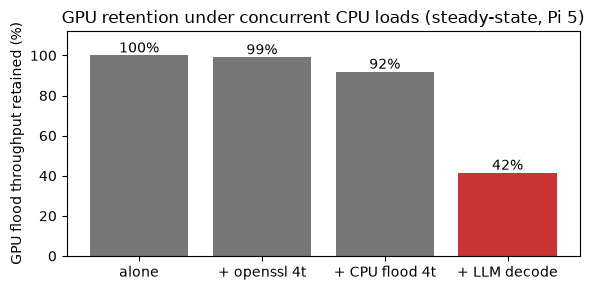

In [4]:
import matplotlib.pyplot as plt

labels = ["alone", "+ openssl 4t", "+ CPU flood 4t", "+ LLM decode"]
retained = [100,
            statistics.mean(go) / base * 100,
            statistics.mean(gc) / base * 100,
            883.4 / 2128.0 * 100]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, retained, color=["#777"] * 3 + ["#c33"])
ax.set_ylabel("GPU flood throughput retained (%)")
ax.set_title("GPU retention under concurrent CPU loads (steady-state, Pi 5)")
for i, v in enumerate(retained):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center")
ax.set_ylim(0, 112)
plt.tight_layout()
plt.savefig("gpu_retention.png", dpi=120)
plt.show()

The GPU is the robust side of every pairing except decode, which
streams model weights from DRAM every token: interference tracks the
CPU load's memory traffic.

## The device-visibility A/B

With any Vulkan device visible, llama.cpp places CPU-resident model
weights in host-pinned, write-combined GPU memory even at `-ngl 0`,
which is slow for the CPU reads that dominate decode. The archived A/B
(llama-bench tg64, r=5, cool starts):

In [5]:
A = ART / "ab_vkvisible_2026-08-10"
for tag in ("visible", "hidden"):
    line = [l for l in (A / f"{tag}.log").read_text().splitlines() if "tg64" in l][0]
    print(f"{tag:8s}", line.split("|")[-2].strip(), "t/s")
vis, hid = (float([l for l in (A / f"{t}.log").read_text().splitlines() if "tg64" in l][0]
                  .split("|")[-2].split("\u00b1")[0]) for t in ("visible", "hidden"))
print(f"\ngain from hiding the device: {hid/vis*100-100:.1f}%")

visible  9.68 ± 0.00 t/s
hidden   11.59 ± 0.00 t/s

gain from hiding the device: 19.7%


## Rerunning live

On the Pi:

```
OUT=/tmp/conc_steady bash pi/flood/conc_steady_bench.sh
OUT=/tmp/cpu_steady bash pi/flood/cpu_steady_bench.sh
OUT=/tmp/genload2 bash pi/flood/genload2_bench.sh
python3 pi/flood/analyze_conc_bench.py /tmp/conc_steady 4000
```